# 06: Forecasting


## Objective
Generate final forecasts for the next 30 days using the best performing model.

## Tasks
- Select best model based on evaluation
- Generate 30-day forecasts
- Calculate confidence intervals
- Visualize forecasts with historical data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from datetime import datetime, timedelta

try:
    import tensorflow as tf
    from tensorflow import keras
    from sklearn.preprocessing import MinMaxScaler
    TENSORFLOW_AVAILABLE = True
except ImportError:
    TENSORFLOW_AVAILABLE = False

# Setup paths
PROJECT_ROOT = '/content/hospital_admissions_forecasting'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
DATA_RAW = os.path.join(DATA_DIR, 'raw')
DATA_PROCESSED = os.path.join(DATA_DIR, 'processed')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')
RESULTS_PATH = os.path.join(PROJECT_ROOT, 'results', 'forecasts')

for path in [DATA_RAW, DATA_PROCESSED, MODELS_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)

# Google Drive mounting (optional, for persistent storage)
DRIVE_MOUNTED = False
DRIVE_DATA_PROCESSED = None
DRIVE_MODELS_PATH = None
DRIVE_RESULTS_PATH = None

try:
    from google.colab import drive
    # Check if drive is already mounted
    if os.path.exists('/content/drive'):
        DRIVE_MOUNTED = True
        print("✓ Google Drive already mounted")
    else:
        # Mount Google Drive
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive')
        DRIVE_MOUNTED = True
        print("✓ Google Drive mounted successfully")

    # Set up Google Drive paths
    if DRIVE_MOUNTED:
        DRIVE_ROOT = '/content/drive/MyDrive/hospital_admissions_forecasting'
        DRIVE_DATA_PROCESSED = os.path.join(DRIVE_ROOT, 'data', 'processed')
        DRIVE_MODELS_PATH = os.path.join(DRIVE_ROOT, 'models')
        DRIVE_RESULTS_PATH = os.path.join(DRIVE_ROOT, 'results', 'forecasts')
        os.makedirs(DRIVE_DATA_PROCESSED, exist_ok=True)
        os.makedirs(DRIVE_MODELS_PATH, exist_ok=True)
        os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)
        print(f"✓ Google Drive paths configured: {DRIVE_ROOT}")
except ImportError:
    print("ℹ️  Not running in Google Colab (will only check local paths)")
except Exception as e:
    print(f"⚠️  Could not mount Google Drive: {e}")
    print("   Will continue with local Colab paths only")

# Helper functions for saving/loading files
def save_file(data, filename, local_path, drive_path=None, **kwargs):
    """Save file to both local and Google Drive (if available)."""
    # Save to local
    local_file = os.path.join(local_path, filename)
    if isinstance(data, pd.DataFrame):
        data.to_csv(local_file, **kwargs)
    elif isinstance(data, (dict, list)) and filename.endswith('.json'):
        import json
        with open(local_file, 'w') as f:
            json.dump(data, f, **kwargs)
    elif filename.endswith('.pkl'):
        import pickle
        with open(local_file, 'wb') as f:
            pickle.dump(data, f)
    elif hasattr(data, 'save'):
        data.save(local_file)
    print(f"✓ Saved to local: {local_file}")
    
    # Save to Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if isinstance(data, pd.DataFrame):
                data.to_csv(drive_file, **kwargs)
            elif isinstance(data, (dict, list)) and filename.endswith('.json'):
                import json
                with open(drive_file, 'w') as f:
                    json.dump(data, f, **kwargs)
            elif filename.endswith('.pkl'):
                import pickle
                with open(drive_file, 'wb') as f:
                    pickle.dump(data, f)
            elif hasattr(data, 'save'):
                data.save(drive_file)
            print(f"✓ Saved to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save to Google Drive: {e}")

def save_plot(fig, filename, local_path, drive_path=None, **kwargs):
    """Save plot to both local and Google Drive."""
    local_file = os.path.join(local_path, filename)
    fig.savefig(local_file, **kwargs)
    print(f"✓ Saved plot to local: {local_file}")
    
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            fig.savefig(drive_file, **kwargs)
            print(f"✓ Saved plot to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save plot to Google Drive: {e}")

def load_file(filename, local_path, drive_path=None):
    """Load file from local or Google Drive (local priority)."""
    # Try local first
    local_file = os.path.join(local_path, filename)
    if os.path.exists(local_file):
        if filename.endswith('.csv'):
            return pd.read_csv(local_file, index_col=0, parse_dates=True)
        elif filename.endswith('.pkl'):
            import pickle
            with open(local_file, 'rb') as f:
                return pickle.load(f)
        elif filename.endswith('.json'):
            import json
            with open(local_file, 'r') as f:
                return json.load(f)
        elif filename.endswith('.h5'):
            from tensorflow import keras
            return keras.models.load_model(local_file)
    
    # Try Google Drive if local not found
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if os.path.exists(drive_file):
                if filename.endswith('.csv'):
                    return pd.read_csv(drive_file, index_col=0, parse_dates=True)
                elif filename.endswith('.pkl'):
                    import pickle
                    with open(drive_file, 'rb') as f:
                        return pickle.load(f)
                elif filename.endswith('.json'):
                    import json
                    with open(drive_file, 'r') as f:
                        return json.load(f)
                elif filename.endswith('.h5'):
                    from tensorflow import keras
                    return keras.models.load_model(drive_file)
        except Exception as e:
            print(f"⚠️  Could not load from Google Drive: {e}")
    
    return None

# Configuration
FORECAST_HORIZON = 30
TRAIN_TEST_SPLIT = 0.8


## Load Full Dataset and Best Model


In [10]:
# Load daily admissions data
daily_admissions_file = os.path.join(DATA_PROCESSED, 'daily_admissions.csv')
if os.path.exists(daily_admissions_file):
    full_data = pd.read_csv(daily_admissions_file, index_col=0, parse_dates=True)
    if 'admissions' in full_data.columns:
        target_series = full_data['admissions']
    else:
        target_series = full_data.iloc[:, 0]
    print(f"Loaded full dataset: {len(target_series)} days")
    print(f"Date range: {target_series.index.min()} to {target_series.index.max()}")
    print(f"Last recorded date: {target_series.index.max()}")
    print(f"\nForecast will start from: {target_series.index.max() + timedelta(days=1)}")
    print(f"Forecast will end on: {target_series.index.max() + timedelta(days=FORECAST_HORIZON)}")
else:
    print(f"File not found: {daily_admissions_file}")
    print("Please run notebooks 00-03 first to create the data.")
    target_series = pd.Series(dtype=float)


Loaded full dataset: 4383 days
Date range: 2008-01-01 00:00:00 to 2019-12-31 00:00:00
Last recorded date: 2019-12-31 00:00:00

Forecast will start from: 2020-01-01 00:00:00
Forecast will end on: 2020-01-30 00:00:00


## Load Best Model

Select the best performing model from evaluation. Here we'll use SARIMA as an example.


In [11]:
best_model = None
model_name = None
lstm_scaler = None
if TENSORFLOW_AVAILABLE:
    lstm_file = os.path.join(MODELS_PATH, 'lstm_model.h5')
    scaler_file = os.path.join(MODELS_PATH, 'lstm_scaler.pkl')
    if os.path.exists(lstm_file) and os.path.exists(scaler_file):
        try:
            # Try loading with custom objects to handle loss/metric function compatibility
            # The error shows 'mse' is being looked up in keras.metrics
            # Provide custom functions that work for both loss and metric contexts
            def mse_function(y_true, y_pred):
                return tf.reduce_mean(tf.square(y_pred - y_true))
            
            def mae_function(y_true, y_pred):
                return tf.reduce_mean(tf.abs(y_pred - y_true))
            
            custom_objects = {
                'mse': mse_function,  # Works as both loss and metric
                'mae': mae_function,
            }
            
            # Try loading with compile=False (we only need inference, not training)
            best_model = keras.models.load_model(lstm_file, custom_objects=custom_objects, compile=False)
            with open(scaler_file, 'rb') as f:
                lstm_scaler = pickle.load(f)
            model_name = 'LSTM'
            print(f"Loaded {model_name} model")
        except Exception as e:
            print(f"⚠️  Could not load LSTM model: {e}")
            print("   Trying other models...")

if best_model is None:
    sarima_file = os.path.join(MODELS_PATH, 'sarima_model.pkl')
    if os.path.exists(sarima_file):
        try:
            with open(sarima_file, 'rb') as f:
                best_model = pickle.load(f)
            model_name = 'SARIMA'
            print(f"Loaded {model_name} model")
        except Exception as e:
            print(f"⚠️  Could not load SARIMA model: {e}")
    
    if best_model is None:
        arima_file = os.path.join(MODELS_PATH, 'arima_model.pkl')
        if os.path.exists(arima_file):
            try:
                with open(arima_file, 'rb') as f:
                    best_model = pickle.load(f)
                model_name = 'ARIMA'
                print(f"Loaded {model_name} model")
            except Exception as e:
                print(f"⚠️  Could not load ARIMA model: {e}")

if best_model is None:
    print("\n⚠️  No trained models found. Please run notebook 04 first to train models.")


Loaded LSTM model


## Generate Final Forecast


In [ ]:
if best_model is not None and len(target_series) > 0:
    print(f"Generating {FORECAST_HORIZON}-day forecast using {model_name} model...")
    print("Retraining model on full dataset...")
    last_date = target_series.index.max()
    forecast_index = pd.date_range(start=last_date + timedelta(days=1), periods=FORECAST_HORIZON, freq='D')
    if model_name == 'LSTM':
        print("Generating LSTM forecast...")
        SEQUENCE_LENGTH = 30  # Should match the sequence length used in training
        train_scaled = lstm_scaler.transform(target_series.values.reshape(-1, 1)).flatten()
        last_sequence = train_scaled[-SEQUENCE_LENGTH:].reshape(1, SEQUENCE_LENGTH, 1)
        forecast_scaled = []
        current_sequence = last_sequence.copy()
        for _ in range(FORECAST_HORIZON):
            next_pred = best_model.predict(current_sequence, verbose=0)
            # Clip prediction to valid range [0, 1] BEFORE feeding back into model
            # This prevents invalid values from propagating in recursive forecasting
            next_pred = np.clip(next_pred, 0, 1)
            if not np.isfinite(next_pred[0, 0]):
                next_pred[0, 0] = 0.5  # Fallback to middle of range
            forecast_scaled.append(next_pred[0, 0])
            current_sequence = np.append(current_sequence[:, 1:, :], next_pred.reshape(1, 1, 1), axis=1)
        forecast_scaled = np.array(forecast_scaled).reshape(-1, 1)
        # Final safety check
        forecast_scaled = np.nan_to_num(forecast_scaled, nan=0.5, posinf=1.0, neginf=0.0)
        forecast_values = lstm_scaler.inverse_transform(forecast_scaled).flatten()
        # Clean any remaining invalid values
        forecast_values = np.nan_to_num(forecast_values, nan=target_series.mean(), posinf=target_series.max(), neginf=target_series.min())
        historical_std = target_series.std()
        forecast_std = historical_std * 0.8  # Conservative estimate
        conf_int = np.array([
            forecast_values - 1.96 * forecast_std,  # Lower bound (95% CI)
            forecast_values + 1.96 * forecast_std     # Upper bound (95% CI)
        ]).T
    elif model_name == 'SARIMA':
        forecast, conf_int = best_model.predict(n_periods=FORECAST_HORIZON, return_conf_int=True)
        if isinstance(forecast, pd.Series):
            forecast_values = forecast.values
        else:
            forecast_values = np.array(forecast)
    elif model_name == 'ARIMA':
        forecast, conf_int = best_model.predict(n_periods=FORECAST_HORIZON, return_conf_int=True)
        if isinstance(forecast, pd.Series):
            forecast_values = forecast.values
        else:
            forecast_values = np.array(forecast)
    else:
        forecast_values = np.array([])
        conf_int = None
    forecast_df = pd.DataFrame({
        'forecast': forecast_values,
        'lower_bound': conf_int[:, 0] if conf_int is not None else None,
        'upper_bound': conf_int[:, 1] if conf_int is not None else None
    }, index=forecast_index)
    forecast_df['forecast'] = forecast_df['forecast'].clip(lower=0)
    if conf_int is not None:
        forecast_df['lower_bound'] = forecast_df['lower_bound'].clip(lower=0)
        forecast_df['upper_bound'] = forecast_df['upper_bound'].clip(lower=0)
    print(f"\n✓ Forecast generated for {len(forecast_df)} days")
    print(f"\nForecast summary:")
    print(forecast_df.describe())
    save_file(forecast_df, 'final_forecast.csv', RESULTS_PATH, DRIVE_RESULTS_PATH)
    print(f"\n✓ Forecast saved")
else:
    print("Cannot generate forecast - missing model or data")
    forecast_df = pd.DataFrame()


Generating 30-day forecast using LSTM model...
Retraining model on full dataset...
Generating LSTM forecast...

✓ Forecast generated for 30 days

Forecast summary:
        forecast  lower_bound  upper_bound
count  30.000000    30.000000    30.000000
mean   49.004402    32.220642    65.788155
std     6.727377     6.727378     6.727377
min    37.027374    20.243622    53.811127
25%    42.271956    25.488204    59.055709
50%    52.572456    35.788704    69.356209
75%    54.220767    37.437015    71.004519
max    55.896683    39.112930    72.680435

✓ Forecast saved to: /content/hospital_admissions_forecasting/results/forecasts/final_forecast.csv


## Visualize Final Forecast


✓ Forecast visualization saved to: /content/hospital_admissions_forecasting/results/forecasts/final_forecast_plot.png


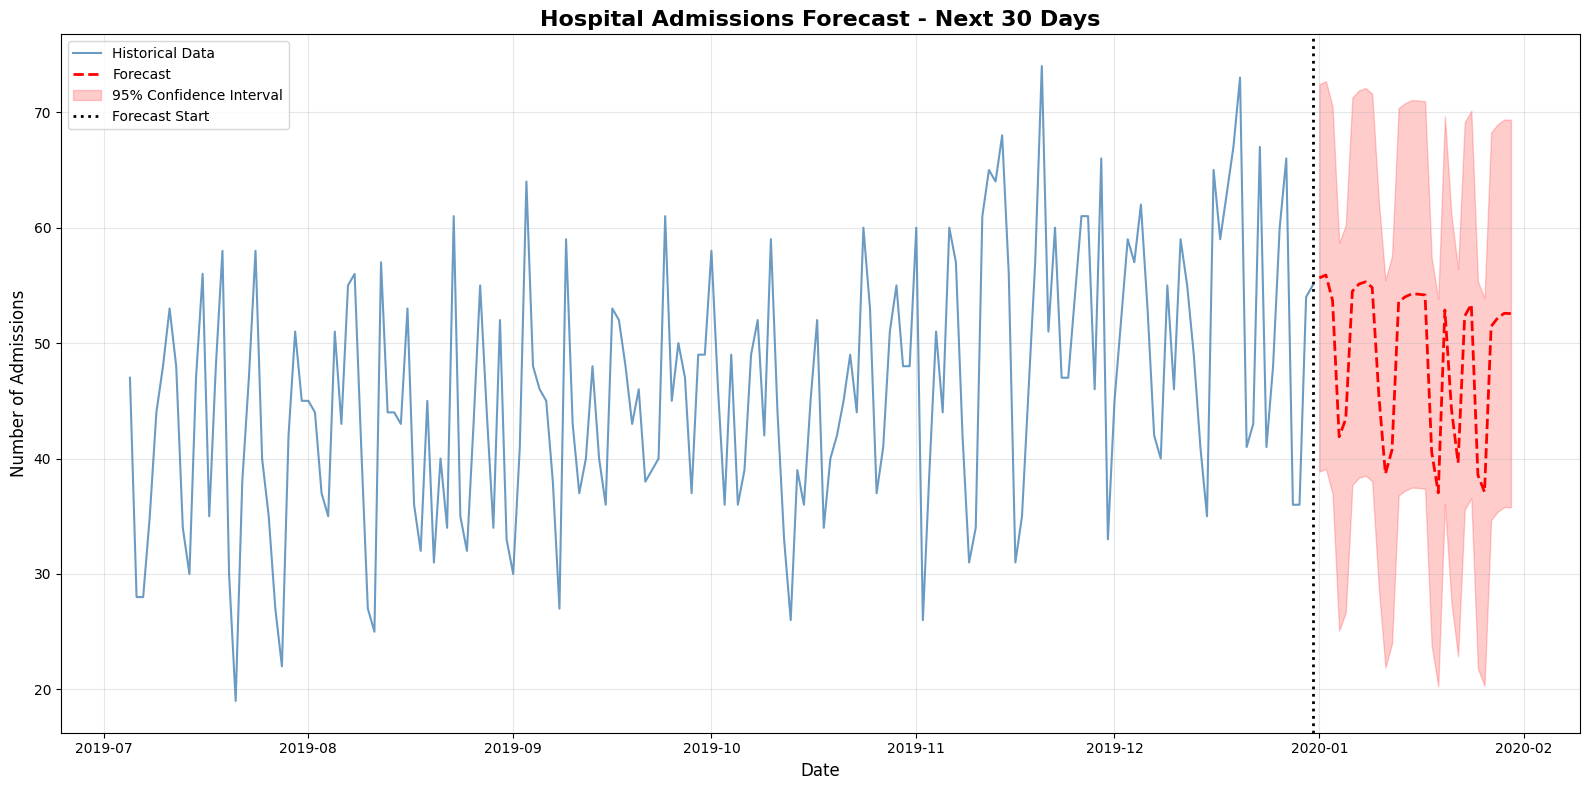

In [ ]:
if len(forecast_df) > 0 and len(target_series) > 0:
    plt.figure(figsize=(16, 8))
    historical_start = max(0, len(target_series) - 180)
    historical_data = target_series.iloc[historical_start:]
    plt.plot(historical_data.index, historical_data.values, 
             label='Historical Data', color='steelblue', linewidth=1.5, alpha=0.8)
    plt.plot(forecast_df.index, forecast_df['forecast'].values,
             label='Forecast', color='red', linewidth=2, linestyle='--')
    if 'lower_bound' in forecast_df.columns and 'upper_bound' in forecast_df.columns:
        plt.fill_between(forecast_df.index, 
                        forecast_df['lower_bound'].values,
                        forecast_df['upper_bound'].values,
                        alpha=0.2, color='red', label='95% Confidence Interval')
    plt.axvline(x=target_series.index.max(), color='black', linestyle=':', 
                linewidth=2, label='Forecast Start')
    plt.title(f'Hospital Admissions Forecast - Next {FORECAST_HORIZON} Days', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Admissions', fontsize=12)
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_plot(plt.gcf(), 'final_forecast_plot.png', RESULTS_PATH, DRIVE_RESULTS_PATH, 
             dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Cannot create visualization - missing forecast or data")


## Staffing Needs Forecasting with Confidence Intervals

Convert admissions forecasts to staffing requirements with uncertainty quantification for operational planning.


In [ ]:
# Convert admissions forecasts to staffing requirements with uncertainty quantification

print("=" * 70)
print("STAFFING NEEDS FORECASTING")
print("=" * 70)

# Configuration for staffing calculations
STAFF_PER_PATIENT = 1.5  # Nurses per patient (industry standard: 1.2-2.0)
STAFF_PER_ADMISSION = 0.8  # Additional staff per new admission (triage, processing)
MIN_STAFF = 20  # Minimum staff required regardless of patient count
SHIFT_MULTIPLIER = 3  # Total staff needed for 3 shifts (day, evening, night)

def calculate_staffing_needs(admissions_forecast, 
                             lower_bound=None, 
                             upper_bound=None,
                             staff_per_patient=STAFF_PER_PATIENT,
                             staff_per_admission=STAFF_PER_ADMISSION,
                             min_staff=MIN_STAFF,
                             shift_multiplier=SHIFT_MULTIPLIER):
    """
    Calculate staffing needs from admissions forecast.
    
    Staffing formula:
    - Base staff = (admissions * staff_per_patient) + (new_admissions * staff_per_admission)
    - Total staff = max(min_staff, base_staff) * shift_multiplier
    
    With confidence intervals:
    - Lower bound staffing = conservative estimate (use upper bound admissions for safety)
    - Upper bound staffing = optimistic estimate (use lower bound admissions)
    - This ensures we plan for worst-case scenarios
    """
    # Base staffing calculation
    base_staff = (admissions_forecast * staff_per_patient) + (admissions_forecast * staff_per_admission)
    base_staff = np.maximum(min_staff, base_staff)
    total_staff = base_staff * shift_multiplier
    
    result = {
        'staffing_median': total_staff.round().astype(int),
        'staffing_base': base_staff.round().astype(int)
    }
    
    # Calculate confidence intervals if provided
    if lower_bound is not None and upper_bound is not None:
        # For staffing planning: use UPPER bound admissions for LOWER bound staffing (worst case)
        # This ensures we have enough staff even in high-admission scenarios
        worst_case_admissions = upper_bound  # Higher admissions = more staff needed
        best_case_admissions = lower_bound   # Lower admissions = less staff needed
        
        worst_case_base = (worst_case_admissions * staff_per_patient) + (worst_case_admissions * staff_per_admission)
        worst_case_base = np.maximum(min_staff, worst_case_base)
        worst_case_total = worst_case_base * shift_multiplier
        
        best_case_base = (best_case_admissions * staff_per_patient) + (best_case_admissions * staff_per_admission)
        best_case_base = np.maximum(min_staff, best_case_base)
        best_case_total = best_case_base * shift_multiplier
        
        result['staffing_lower'] = worst_case_total.round().astype(int)  # Worst case = more staff
        result['staffing_upper'] = best_case_total.round().astype(int)    # Best case = less staff
        result['staffing_range'] = (worst_case_total - best_case_total).round().astype(int)
    
    return result

# Calculate staffing needs from the forecast generated in this notebook
if len(forecast_df) > 0:
    print("\nCalculating staffing from forecast...")
    
    # Use the forecast from this notebook
    admissions_forecast = forecast_df['forecast'].values
    forecast_dates = forecast_df.index
    
    # Check if confidence intervals are available
    if 'lower_bound' in forecast_df.columns and 'upper_bound' in forecast_df.columns:
        lower_bound = forecast_df['lower_bound'].values
        upper_bound = forecast_df['upper_bound'].values
        staffing_result = calculate_staffing_needs(
            admissions_forecast,
            lower_bound=lower_bound,
            upper_bound=upper_bound
        )
        print(f"  ✓ Staffing calculated with confidence intervals")
        print(f"    Median: {staffing_result['staffing_median'].mean():.0f} staff/day")
        print(f"    Range: {staffing_result['staffing_lower'].mean():.0f} - {staffing_result['staffing_upper'].mean():.0f} staff/day (95% interval)")
    else:
        staffing_result = calculate_staffing_needs(admissions_forecast)
        print(f"  ✓ Staffing calculated (point forecast only)")
        print(f"    Median: {staffing_result['staffing_median'].mean():.0f} staff/day")
    
    staffing_result['forecast_date'] = forecast_dates
    
    # Create staffing forecast DataFrame
    staffing_df = pd.DataFrame({
        'date': staffing_result['forecast_date'],
        'staffing_median': staffing_result['staffing_median'],
        'staffing_base': staffing_result['staffing_base']
    })
    
    if 'staffing_lower' in staffing_result:
        staffing_df['staffing_lower_95pct'] = staffing_result['staffing_lower']
        staffing_df['staffing_upper_95pct'] = staffing_result['staffing_upper']
        staffing_df['staffing_range'] = staffing_result['staffing_range']
    
    # Save staffing forecasts
    save_file(staffing_df, 'staffing_forecast.csv', RESULTS_PATH, DRIVE_RESULTS_PATH)
    print(f"\n✓ Staffing forecasts saved")
    
    # Create visualization with confidence intervals
    print("\nCreating staffing forecast visualization...")
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    # Plot 1: Staffing forecast with confidence intervals
    axes[0].plot(staffing_result['forecast_date'], staffing_result['staffing_median'], 
                label='Median Staffing Need', color='blue', linewidth=2)
    
    if 'staffing_lower' in staffing_result:
        axes[0].fill_between(
            staffing_result['forecast_date'],
            staffing_result['staffing_lower'],
            staffing_result['staffing_upper'],
            alpha=0.3, color='blue', label='95% Confidence Interval (Staffing Range)'
        )
        # Add annotations for decision-making
        axes[0].axhline(y=staffing_result['staffing_upper'].quantile(0.95), 
                       color='red', linestyle='--', alpha=0.5, 
                       label=f"95th Percentile: {staffing_result['staffing_upper'].quantile(0.95):.0f} staff")
        axes[0].axhline(y=staffing_result['staffing_median'].mean(), 
                       color='green', linestyle='--', alpha=0.5,
                       label=f"Average: {staffing_result['staffing_median'].mean():.0f} staff")
    
    axes[0].set_title('Staffing Needs Forecast', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Required Staff (Total across 3 shifts)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Staffing range (uncertainty) over time
    if 'staffing_range' in staffing_result:
        axes[1].plot(staffing_result['forecast_date'], staffing_result['staffing_range'],
                    label='Staffing Uncertainty Range', color='orange', linewidth=2)
        axes[1].axhline(y=staffing_result['staffing_range'].mean(), 
                       color='red', linestyle='--', alpha=0.5,
                       label=f"Average Uncertainty: ±{staffing_result['staffing_range'].mean():.0f} staff")
        axes[1].set_title('Staffing Forecast Uncertainty (95% Interval Width)', 
                         fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Date')
        axes[1].set_ylabel('Staffing Range (Upper - Lower)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_plot(plt.gcf(), 'staffing_forecast.png', RESULTS_PATH, DRIVE_RESULTS_PATH, 
             dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print decision-making summary
    print(f"\n{'='*70}")
    print("STAFFING DECISION-MAKING SUMMARY")
    print(f"{'='*70}")
    print(f"\nConfiguration:")
    print(f"  Staff per patient: {STAFF_PER_PATIENT}")
    print(f"  Staff per admission: {STAFF_PER_ADMISSION}")
    print(f"  Minimum staff: {MIN_STAFF}")
    print(f"  Shifts: {SHIFT_MULTIPLIER} (day, evening, night)")
    
    if 'staffing_lower' in staffing_result:
        print(f"\nRecommended Staffing Plan:")
        print(f"  Average daily staffing: {staffing_result['staffing_median'].mean():.0f} staff")
        print(f"  Peak staffing (95th percentile): {staffing_result['staffing_upper'].quantile(0.95):.0f} staff")
        print(f"  Minimum staffing (5th percentile): {staffing_result['staffing_lower'].quantile(0.05):.0f} staff")
        print(f"  Average uncertainty range: ±{staffing_result['staffing_range'].mean():.0f} staff/day")
        print(f"\n  💡 Decision Guidance:")
        print(f"     - Plan for {staffing_result['staffing_upper'].quantile(0.95):.0f} staff to cover 95% of scenarios")
        print(f"     - Budget for {staffing_result['staffing_median'].mean():.0f} staff as baseline")
        print(f"     - Maintain flexibility of ±{staffing_result['staffing_range'].mean():.0f} staff for daily adjustments")
    else:
        print(f"\nRecommended Staffing Plan:")
        print(f"  Average daily staffing: {staffing_result['staffing_median'].mean():.0f} staff")
        print(f"  ⚠️  No confidence intervals available - consider using a model with quantile regression")
    
    print(f"\n{'='*70}")
else:
    print("\n⚠️  No forecast available for staffing calculation")
    print("   Generate forecast first")


## Bed Occupancy and Capacity Utilization Forecasting

Calculate bed occupancy forecasts and capacity utilization based on forecasted admissions.


In [ ]:
# Calculate bed occupancy forecasts and capacity utilization

print("=" * 70)
print("BED OCCUPANCY & CAPACITY UTILIZATION FORECASTING")
print("=" * 70)

# Load historical KPI data to get average length of stay and bed occupancy patterns
kpi_data = load_file('daily_kpis.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if kpi_data is not None and len(forecast_df) > 0:
    print("\nLoading historical KPI data...")
    
    # Get historical average length of stay (ALOS)
    if 'avg_length_of_stay' in kpi_data.columns:
        historical_alos = kpi_data['avg_length_of_stay'].dropna()
        # Use recent average ALOS (last 90 days) for forecasting
        recent_alos = historical_alos.iloc[-90:].mean() if len(historical_alos) >= 90 else historical_alos.mean()
        print(f"  ✓ Historical Average Length of Stay: {recent_alos:.2f} days")
        print(f"    (Using last 90 days average: {historical_alos.iloc[-90:].mean():.2f} days)")
    else:
        # Fallback: use a default ALOS if not available
        recent_alos = 5.0  # Typical hospital ALOS
        print(f"  ⚠️  ALOS not found in KPI data, using default: {recent_alos:.2f} days")
    
    # Get historical bed occupancy rate to estimate capacity
    if 'bed_occupancy_rate' in kpi_data.columns:
        historical_occupancy = kpi_data['bed_occupancy_rate'].dropna()
        # Estimate hospital capacity from historical data
        # Capacity = max(historical admissions) / max(historical occupancy rate)
        # Or use recent peak occupancy
        if 'daily_admissions' in kpi_data.columns or 'admissions' in kpi_data.columns:
            admissions_col = 'daily_admissions' if 'daily_admissions' in kpi_data.columns else 'admissions'
            historical_admissions = kpi_data[admissions_col].dropna()
            # Estimate capacity: peak occupancy suggests near-capacity
            peak_occupancy = historical_occupancy.max()
            peak_admissions = historical_admissions.max()
            # Rough estimate: capacity ≈ peak admissions / peak occupancy (if occupancy was near 100%)
            # Or use a more conservative estimate based on 95th percentile
            capacity_estimate = historical_admissions.quantile(0.95) / max(historical_occupancy.quantile(0.95), 0.85)
        else:
            # Fallback: estimate from occupancy rate alone
            # If we know typical occupancy is around 80%, we can estimate capacity
            capacity_estimate = None
            print(f"  ⚠️  Cannot estimate capacity from admissions data")
    else:
        historical_occupancy = None
        capacity_estimate = None
        print(f"  ⚠️  Bed occupancy rate not found in KPI data")
    
    # Calculate bed occupancy forecast
    print(f"\nCalculating bed occupancy forecast...")
    
    # Bed occupancy calculation:
    # Occupied beds = Previous occupied beds - Discharges + New Admissions
    # For forecasting, we use a simplified model:
    # Occupied beds(t) ≈ Occupied beds(t-1) * (1 - 1/ALOS) + Admissions(t)
    # Or more simply: Occupied beds ≈ Admissions * ALOS (steady-state approximation)
    
    # Get last known bed occupancy from historical data
    if historical_occupancy is not None and len(historical_occupancy) > 0:
        last_occupancy_rate = historical_occupancy.iloc[-1]
        # Estimate last occupied beds from occupancy rate
        # We need to know total beds, but we can estimate from admissions
        if 'daily_admissions' in kpi_data.columns or 'admissions' in kpi_data.columns:
            admissions_col = 'daily_admissions' if 'daily_admissions' in kpi_data.columns else 'admissions'
            last_admissions = kpi_data[admissions_col].iloc[-1]
            # Rough estimate: if occupancy rate is known, we can estimate beds
            # But we don't have total beds, so we'll use a different approach
            # Use the relationship: Occupied beds ≈ Admissions * ALOS (in steady state)
            estimated_occupied_beds = last_admissions * recent_alos
        else:
            estimated_occupied_beds = None
    else:
        last_occupancy_rate = None
        estimated_occupied_beds = None
    
    # Forecast bed occupancy using forecasted admissions
    forecast_admissions = forecast_df['forecast'].values
    forecast_dates = forecast_df.index
    
    # Simple model: Occupied beds(t) = Admissions(t) * ALOS
    # This assumes steady-state where discharges balance admissions
    forecast_occupied_beds = forecast_admissions * recent_alos
    
    # If we have confidence intervals for admissions, calculate occupancy intervals
    if 'lower_bound' in forecast_df.columns and 'upper_bound' in forecast_df.columns:
        forecast_occupied_beds_lower = forecast_df['lower_bound'].values * recent_alos
        forecast_occupied_beds_upper = forecast_df['upper_bound'].values * recent_alos
    else:
        forecast_occupied_beds_lower = None
        forecast_occupied_beds_upper = None
    
    # Calculate bed occupancy rate (if we can estimate total capacity)
    if capacity_estimate is not None:
        forecast_occupancy_rate = forecast_occupied_beds / capacity_estimate
        forecast_occupancy_rate = np.clip(forecast_occupancy_rate, 0, 1.5)  # Cap at 150% (overflow)
        
        if forecast_occupied_beds_lower is not None:
            forecast_occupancy_rate_lower = forecast_occupied_beds_lower / capacity_estimate
            forecast_occupancy_rate_upper = forecast_occupied_beds_upper / capacity_estimate
            forecast_occupancy_rate_lower = np.clip(forecast_occupancy_rate_lower, 0, 1.5)
            forecast_occupancy_rate_upper = np.clip(forecast_occupancy_rate_upper, 0, 1.5)
        else:
            forecast_occupancy_rate_lower = None
            forecast_occupancy_rate_upper = None
        
        print(f"  ✓ Estimated hospital capacity: {capacity_estimate:.0f} beds")
    else:
        # If we can't estimate capacity, just report occupied beds
        forecast_occupancy_rate = None
        forecast_occupancy_rate_lower = None
        forecast_occupancy_rate_upper = None
        print(f"  ⚠️  Cannot calculate occupancy rate (capacity unknown)")
        print(f"     Reporting occupied beds instead")
    
    # Calculate capacity utilization
    print(f"\nCalculating capacity utilization...")
    
    if capacity_estimate is not None:
        # Capacity utilization = Forecasted admissions / Capacity
        # This shows how much of capacity is being used by new admissions
        capacity_utilization = forecast_admissions / capacity_estimate
        
        if 'lower_bound' in forecast_df.columns and 'upper_bound' in forecast_df.columns:
            capacity_utilization_lower = forecast_df['lower_bound'].values / capacity_estimate
            capacity_utilization_upper = forecast_df['upper_bound'].values / capacity_estimate
        else:
            capacity_utilization_lower = None
            capacity_utilization_upper = None
        
        print(f"  ✓ Capacity utilization calculated")
    else:
        capacity_utilization = None
        capacity_utilization_lower = None
        capacity_utilization_upper = None
        print(f"  ⚠️  Cannot calculate capacity utilization (capacity unknown)")
    
    # Create forecast DataFrame
    operational_forecast_df = pd.DataFrame({
        'date': forecast_dates,
        'forecasted_admissions': forecast_admissions,
        'forecasted_occupied_beds': forecast_occupied_beds
    })
    
    if forecast_occupancy_rate is not None:
        operational_forecast_df['bed_occupancy_rate'] = forecast_occupancy_rate
        operational_forecast_df['capacity_utilization'] = capacity_utilization
    
    if forecast_occupied_beds_lower is not None:
        operational_forecast_df['occupied_beds_lower'] = forecast_occupied_beds_lower
        operational_forecast_df['occupied_beds_upper'] = forecast_occupied_beds_upper
        
        if forecast_occupancy_rate_lower is not None:
            operational_forecast_df['occupancy_rate_lower'] = forecast_occupancy_rate_lower
            operational_forecast_df['occupancy_rate_upper'] = forecast_occupancy_rate_upper
            operational_forecast_df['capacity_utilization_lower'] = capacity_utilization_lower
            operational_forecast_df['capacity_utilization_upper'] = capacity_utilization_upper
    
    # Save operational forecasts
    save_file(operational_forecast_df, 'operational_forecasts.csv', RESULTS_PATH, DRIVE_RESULTS_PATH)
    print(f"\n✓ Operational forecasts saved")
    
    # Create visualizations
    print("\nCreating operational forecast visualizations...")
    
    # Determine number of subplots needed
    n_plots = 1  # Always show occupied beds
    if forecast_occupancy_rate is not None:
        n_plots += 1
    if capacity_utilization is not None:
        n_plots += 1
    
    fig, axes = plt.subplots(n_plots, 1, figsize=(15, 4 * n_plots))
    if n_plots == 1:
        axes = [axes]
    
    plot_idx = 0
    
    # Plot 1: Occupied beds forecast
    axes[plot_idx].plot(forecast_dates, forecast_occupied_beds, 
                       label='Forecasted Occupied Beds', color='blue', linewidth=2)
    
    if forecast_occupied_beds_lower is not None:
        axes[plot_idx].fill_between(
            forecast_dates,
            forecast_occupied_beds_lower,
            forecast_occupied_beds_upper,
            alpha=0.3, color='blue', label='95% Confidence Interval'
        )
    
    axes[plot_idx].set_title('Bed Occupancy Forecast (Occupied Beds)', 
                            fontsize=14, fontweight='bold')
    axes[plot_idx].set_xlabel('Date')
    axes[plot_idx].set_ylabel('Number of Occupied Beds')
    axes[plot_idx].legend()
    axes[plot_idx].grid(True, alpha=0.3)
    plot_idx += 1
    
    # Plot 2: Bed occupancy rate (if available)
    if forecast_occupancy_rate is not None:
        axes[plot_idx].plot(forecast_dates, forecast_occupancy_rate * 100, 
                          label='Forecasted Occupancy Rate', color='green', linewidth=2)
        
        if forecast_occupancy_rate_lower is not None:
            axes[plot_idx].fill_between(
                forecast_dates,
                forecast_occupancy_rate_lower * 100,
                forecast_occupancy_rate_upper * 100,
                alpha=0.3, color='green', label='95% Confidence Interval'
            )
        
        # Add capacity thresholds
        axes[plot_idx].axhline(y=85, color='orange', linestyle='--', alpha=0.5, 
                             label='Near Capacity (85%)')
        axes[plot_idx].axhline(y=95, color='red', linestyle='--', alpha=0.5, 
                             label='At Capacity (95%)')
        axes[plot_idx].axhline(y=100, color='darkred', linestyle='--', alpha=0.5, 
                             label='Full Capacity (100%)')
        
        axes[plot_idx].set_title('Bed Occupancy Rate Forecast', 
                                fontsize=14, fontweight='bold')
        axes[plot_idx].set_xlabel('Date')
        axes[plot_idx].set_ylabel('Occupancy Rate (%)')
        axes[plot_idx].legend()
        axes[plot_idx].grid(True, alpha=0.3)
        plot_idx += 1
    
    # Plot 3: Capacity utilization (if available)
    if capacity_utilization is not None:
        axes[plot_idx].plot(forecast_dates, capacity_utilization * 100, 
                          label='Capacity Utilization', color='purple', linewidth=2)
        
        if capacity_utilization_lower is not None:
            axes[plot_idx].fill_between(
                forecast_dates,
                capacity_utilization_lower * 100,
                capacity_utilization_upper * 100,
                alpha=0.3, color='purple', label='95% Confidence Interval'
            )
        
        axes[plot_idx].set_title('Capacity Utilization Forecast (New Admissions / Capacity)', 
                                fontsize=14, fontweight='bold')
        axes[plot_idx].set_xlabel('Date')
        axes[plot_idx].set_ylabel('Capacity Utilization (%)')
        axes[plot_idx].legend()
        axes[plot_idx].grid(True, alpha=0.3)
        plot_idx += 1
    
    plt.tight_layout()
    save_plot(plt.gcf(), 'operational_forecasts.png', RESULTS_PATH, DRIVE_RESULTS_PATH, 
             dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print(f"\n{'='*70}")
    print("OPERATIONAL FORECAST SUMMARY")
    print(f"{'='*70}")
    print(f"\nBed Occupancy Forecast:")
    print(f"  Average Length of Stay (ALOS): {recent_alos:.2f} days")
    print(f"  Average occupied beds: {forecast_occupied_beds.mean():.0f} beds")
    print(f"  Peak occupied beds: {forecast_occupied_beds.max():.0f} beds")
    print(f"  Minimum occupied beds: {forecast_occupied_beds.min():.0f} beds")
    
    if forecast_occupancy_rate is not None:
        print(f"\nBed Occupancy Rate:")
        print(f"  Average occupancy rate: {forecast_occupancy_rate.mean() * 100:.1f}%")
        print(f"  Peak occupancy rate: {forecast_occupancy_rate.max() * 100:.1f}%")
        print(f"  Days near capacity (≥85%): {(forecast_occupancy_rate >= 0.85).sum()} days")
        print(f"  Days at capacity (≥95%): {(forecast_occupancy_rate >= 0.95).sum()} days")
        print(f"  Days over capacity (≥100%): {(forecast_occupancy_rate >= 1.0).sum()} days")
    
    if capacity_utilization is not None:
        print(f"\nCapacity Utilization:")
        print(f"  Average utilization: {capacity_utilization.mean() * 100:.1f}%")
        print(f"  Peak utilization: {capacity_utilization.max() * 100:.1f}%")
        print(f"  Estimated capacity: {capacity_estimate:.0f} beds")
    
    print(f"\n{'='*70}")
    
else:
    print("\n⚠️  Cannot calculate operational forecasts")
    if kpi_data is None:
        print("   KPI data not found - please run notebook 02 first")
    if len(forecast_df) == 0:
        print("   Forecast data not available - generate forecast first")


## Summary

This notebook:
- ✅ Loaded full dataset and best performing model
- ✅ Generated 30-day forecast
- ✅ Created forecast visualization with confidence intervals
- ✅ Calculated staffing needs from admissions forecast with uncertainty quantification
- ✅ Calculated bed occupancy forecasts based on forecasted admissions and average length of stay
- ✅ Calculated capacity utilization (forecasted admissions relative to hospital capacity)
- ✅ Saved all forecast and operational results

**Next Steps:**
- Use forecast and operational results in your final report
- Integrate with operational dashboards (optional)
- Present findings in presentation (optional)
